# 4. Comprendre l'analyse ICU Nantes — de l'image satellite à l'app

Ce notebook explique, en langage simple et avec du code qui tourne vraiment,
comment on passe d'une **image satellite brute** à l'**application
Streamlit** (`app.py`) de ce projet. Public visé : quelqu'un qui découvre le
sujet — moi-même en train de me remettre à niveau, ou un·e recruteur·se
curieux·se mais pas forcément expert en télédétection.

**La question du projet, en une phrase** : *où fait-il plus chaud à Nantes,
et pourquoi ?*

Ce notebook suit tout le trajet : résolution des images → assemblage des
scènes satellite → calcul de l'anomalie de température → seuil "îlot de
chaleur" → modèle explicatif → SHAP → limites du projet.

## 1. Pourquoi la résolution 100 m limite ce qu'on peut voir

Une image satellite est une grille de pixels : chaque pixel a **une seule
valeur** pour toute sa surface. Si un pixel fait 100 m de côté, ça veut dire
qu'une rue, les jardins autour, et un bout de parking peuvent tous se
retrouver **mélangés dans le même pixel** — on ne peut plus les distinguer.

Pour rendre ça concret, on simule un "quartier" fictif à très haute
résolution (1 m/pixel, comme si on le voyait à l'œil), puis on regarde ce
qu'il devient une fois dégradé à 10 m/pixel (résolution Sentinel-2) et à
100 m/pixel (résolution thermique Landsat, celle utilisée pour l'ICU).

**Attention** : l'image ci-dessous est une **simulation synthétique** (pas
une vraie photo de Nantes) — elle sert juste à illustrer l'effet de la
résolution.

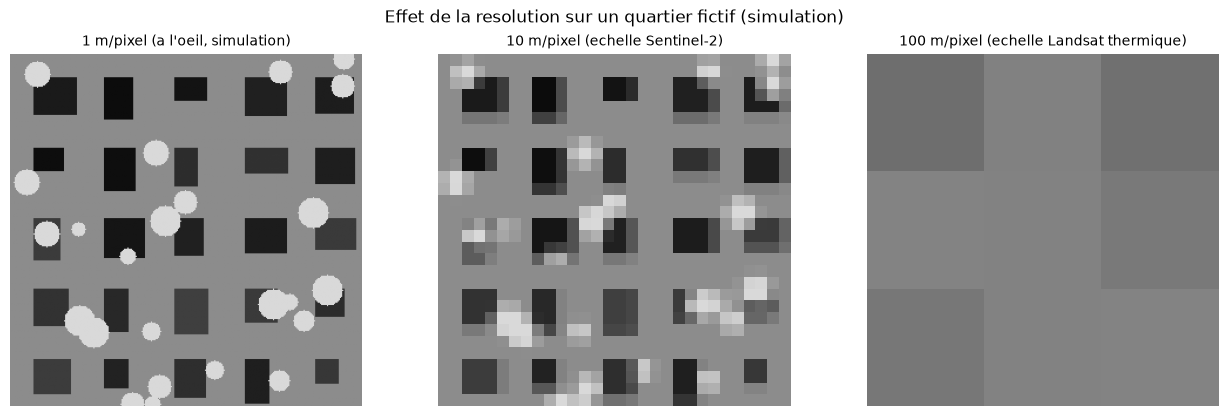

Un pixel Landsat de 100 m represente 10,000 m2 au sol, soit environ 1,4 terrain de football.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
FINE = 300  # "300 m x 300 m" de quartier, a 1 m/pixel

# On dessine un quartier fictif : rues (fond clair), batiments (blocs
# sombres) et arbres (taches claires), a la resolution fine (1 m/pixel).
quartier = np.full((FINE, FINE), 0.55)  # fond "sol/route"
for cx in range(20, FINE, 60):
    for cy in range(20, FINE, 60):
        w, h = rng.integers(20, 40), rng.integers(20, 40)
        quartier[cy:cy + h, cx:cx + w] = rng.uniform(0.05, 0.25)  # batiment sombre
for _ in range(25):
    cx, cy = rng.integers(0, FINE, 2)
    r = rng.integers(6, 14)
    yy, xx = np.ogrid[:FINE, :FINE]
    mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    quartier[mask] = 0.85  # canopee (claire pour le contraste du cmap)


def degrade(img, facteur):
    h, w = img.shape
    h2, w2 = h // facteur, w // facteur
    return img[:h2 * facteur, :w2 * facteur].reshape(h2, facteur, w2, facteur).mean(axis=(1, 3))


quartier_10m = degrade(quartier, 10)
quartier_100m = degrade(quartier, 100)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
titres = ["1 m/pixel (a l'oeil, simulation)", "10 m/pixel (echelle Sentinel-2)",
          "100 m/pixel (echelle Landsat thermique)"]
for ax, img, titre in zip(axes, [quartier, quartier_10m, quartier_100m], titres):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(titre, fontsize=10)
    ax.axis("off")
plt.suptitle("Effet de la resolution sur un quartier fictif (simulation)")
plt.tight_layout()
plt.show()

print(f"Un pixel Landsat de 100 m represente {100*100:,} m2 au sol, "
      "soit environ 1,4 terrain de football.")

**Ce qu'on retient** : à 100 m/pixel (image de droite), on ne
distingue plus ni rue, ni bâtiment, ni arbre individuel — chaque pixel donne
une **moyenne** de tout ce qu'il contient. C'est pour ça que le projet parle
d'ICU à l'échelle du *quartier*, pas de la rue : c'est une limite physique du
capteur thermique Landsat, pas un choix arbitraire.

## 2. D'une scène satellite à une carte

Un satellite comme Landsat ne prend pas "une photo de Nantes" à la demande :
il suit une **orbite fixe** et prend des images en continu le long de sa
trace au sol. Chaque image ("scène") couvre une bande d'environ 185 km de
large, mais **légèrement inclinée** par rapport au nord (l'orbite de Landsat
n'est pas parfaitement verticale) — pas un joli rectangle aligné sur notre
zone d'étude.

Nantes Métropole se trouve pile **à la frontière entre deux scènes
adjacentes** (deux "paths" du découpage standard WRS-2 utilisé par Landsat).
Le schéma ci-dessous illustre ça : notre emprise (le rectangle noir) est
chevauchée par deux scènes inclinées (path 201 et path 202).

**Attention** : ce schéma est une **illustration simplifiée** de la
géométrie (pas les vraies données pixel), construite pour montrer le
principe qu'on a vérifié dans les faits (voir plus bas).

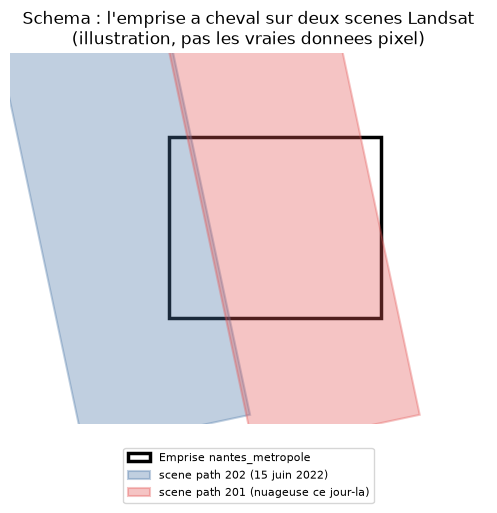

In [2]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6, 5))

aoi = patches.Rectangle((1, 1), 4, 3.4, linewidth=2.5, edgecolor="black",
                         facecolor="none", label="Emprise nantes_metropole")
ax.add_patch(aoi)

scenes = [(-0.6, "#4C78A8", "scene path 202 (15 juin 2022)"),
          (2.6, "#E45756", "scene path 201 (nuageuse ce jour-la)")]
for dx, color, nom in scenes:
    scene = patches.Rectangle((dx, -1.5), 3.2, 8, angle=12,
                               facecolor=color, alpha=0.35, edgecolor=color,
                               linewidth=1.5, label=nom)
    ax.add_patch(scene)

ax.set_xlim(-2, 7)
ax.set_ylim(-1, 6)
ax.set_aspect("equal")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), fontsize=8)
ax.set_title("Schema : l'emprise a cheval sur deux scenes Landsat\n(illustration, pas les vraies donnees pixel)")
ax.axis("off")
plt.tight_layout()
plt.show()

**Pourquoi on "mosaïque" plusieurs scènes** : si une seule des deux
scènes est disponible et propre (sans nuage) un jour donné, on n'a des
données valides que sur la portion de l'emprise couverte par *cette*
scène — le reste du rectangle reste vide. On l'a constaté pour de vrai sur
ce projet : le 15 juin 2022, la scène du path 202 était parfaitement claire
(0,02 % de nuages), mais la scène du path 201 nécessaire pour compléter
l'emprise était nuageuse à chaque passage disponible (jusqu'à 81 % de
nuages) — impossible de compléter cette date, qui a donc été **exclue** du
jeu de données final (voir `gee_extraction.py`, fonction `build_ymosaic`,
qui mosaïque plusieurs scènes proches dans le temps et vérifie qu'au moins
98 % de l'emprise est couverte avant d'accepter une date).

## 3. De la température brute à l'anomalie ΔLST

Pourquoi ne compare-t-on pas simplement la température brute d'un jour à
l'autre ? Parce que la météo change : un jour de canicule, **toute la
ville** est plus chaude, pas seulement les "îlots de chaleur". Ce qui
caractérise un vrai îlot de chaleur urbain, c'est d'être **plus chaud que le
reste de la métropole ce jour-là** — pas plus chaud dans l'absolu.

Exemple chiffré simple avec 5 lieux fictifs, sur 2 jours très différents en
température (un jour de canicule, un jour plus frais) :

In [3]:
import pandas as pd

exemple = pd.DataFrame({
    "lieu": ["Centre dense", "Parc urbain", "Pavillonnaire", "Zone indus.", "Bord de Loire"],
    "LST_jour_canicule": [42.0, 34.0, 38.0, 43.5, 30.0],
    "LST_jour_frais": [29.0, 22.0, 25.5, 30.0, 18.5],
})
for col in ["LST_jour_canicule", "LST_jour_frais"]:
    mediane = exemple[col].median()
    exemple[col.replace("LST", "delta")] = (exemple[col] - mediane).round(1)

print(exemple.to_string(index=False))
msg = ("La temperature BRUTE change enormement entre les deux jours (+13C "
       "en moyenne), mais le classement relatif (delta = ecart a la mediane "
       "du jour) reste quasiment identique : le centre dense et la zone "
       "industrielle ressortent chaud les DEUX jours, le bord de Loire "
       "ressort frais les DEUX jours.")
print()
print(msg)

         lieu  LST_jour_canicule  LST_jour_frais  delta_jour_canicule  delta_jour_frais
 Centre dense               42.0            29.0                  4.0               3.5
  Parc urbain               34.0            22.0                 -4.0              -3.5
Pavillonnaire               38.0            25.5                  0.0               0.0
  Zone indus.               43.5            30.0                  5.5               4.5
Bord de Loire               30.0            18.5                 -8.0              -7.0

La temperature BRUTE change enormement entre les deux jours (+13C en moyenne), mais le classement relatif (delta = ecart a la mediane du jour) reste quasiment identique : le centre dense et la zone industrielle ressortent chaud les DEUX jours, le bord de Loire ressort frais les DEUX jours.


On visualise maintenant la même idée sur une **vraie carte** du
projet (`data/raw/Y_lst_100m_nantes_metropole_2025-08-11.tif` et
`data/icu/delta_lst_nantes_metropole_2025-08-11.tif`, produits par
`gee_extraction.py` et `compute_icu.py`) :

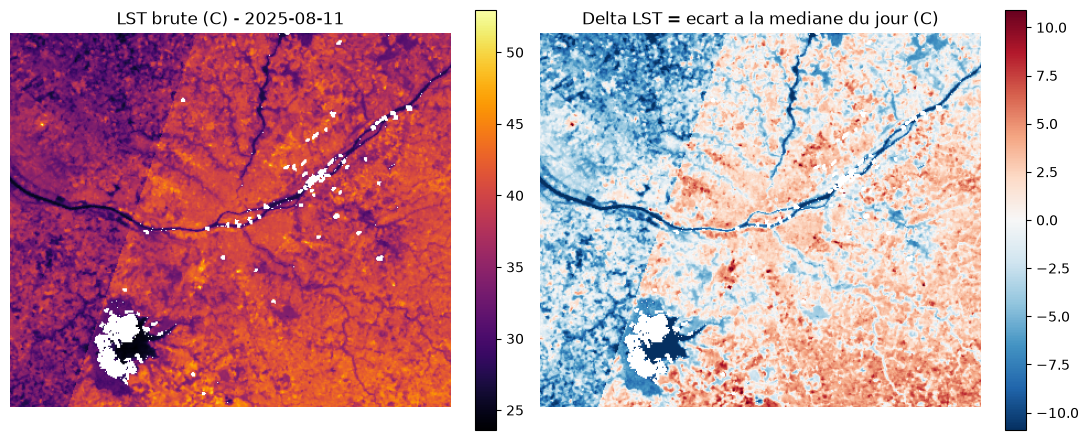

LST brute : mediane 37.8 C (min 23.6, max 53.0)
Delta LST : mediane -0.0 C par construction (min -14.2, max 15.1)


In [4]:
import rasterio


def read_band(path):
    with rasterio.open(path) as src:
        return src.read(1, masked=True).filled(np.nan)


lst_brut = read_band("data/raw/Y_lst_100m_nantes_metropole_2025-08-11.tif")
delta_lst = read_band("data/icu/delta_lst_nantes_metropole_2025-08-11.tif")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(lst_brut, cmap="inferno")
axes[0].set_title("LST brute (C) - 2025-08-11")
plt.colorbar(im0, ax=axes[0], fraction=0.046)
span = np.nanpercentile(np.abs(delta_lst), 99)
im1 = axes[1].imshow(delta_lst, cmap="RdBu_r", vmin=-span, vmax=span)
axes[1].set_title("Delta LST = ecart a la mediane du jour (C)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"LST brute : mediane {np.nanmedian(lst_brut):.1f} C "
      f"(min {np.nanmin(lst_brut):.1f}, max {np.nanmax(lst_brut):.1f})")
print(f"Delta LST : mediane {np.nanmedian(delta_lst):.1f} C par construction "
      f"(min {np.nanmin(delta_lst):.1f}, max {np.nanmax(delta_lst):.1f})")

**Ce qu'on retient** : la carte de gauche montre une température qui
dépend surtout de la météo du jour (toute la carte est globalement chaude ou
froide). La carte de droite (ΔLST) fait disparaître cet effet global et fait
ressortir uniquement la **structure thermique propre à Nantes** — c'est elle
qui sert de cible (`y`) au modèle explicatif.

## 4. Le seuil ICU : un choix de sensibilité, pas une vérité absolue

Le projet classe un pixel "en surchauffe" (ICU) si son ΔLST dépasse **+2°C**
par défaut. Mais pourquoi 2°C et pas 1°C ou 3°C ? On regarde la distribution
réelle des ΔLST (toutes dates confondues, `data/table.parquet`) et l'effet
de changer ce seuil.

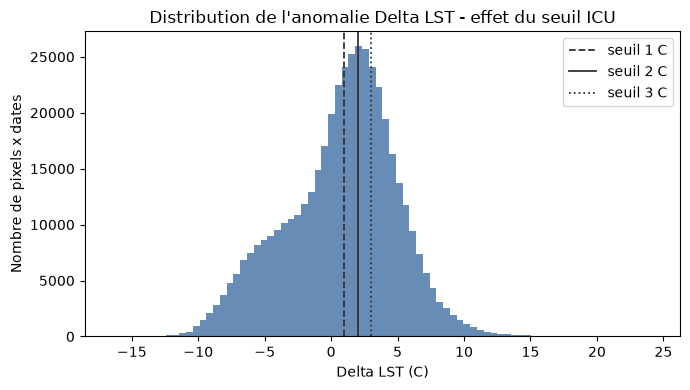

Seuil 1 C -> 53.0 % des pixels classes 'ICU'
Seuil 2 C -> 42.1 % des pixels classes 'ICU'
Seuil 3 C -> 31.0 % des pixels classes 'ICU'


In [5]:
df = pd.read_parquet("data/table.parquet")
delta = df["delta_lst_c"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(delta, bins=80, color="#4C78A8", alpha=0.85)
for seuil, style in zip([1.0, 2.0, 3.0], ["--", "-", ":"]):
    ax.axvline(seuil, color="#333", linestyle=style, linewidth=1.3,
               label=f"seuil {seuil:.0f} C")
ax.set_xlabel("Delta LST (C)")
ax.set_ylabel("Nombre de pixels x dates")
ax.legend()
ax.set_title("Distribution de l'anomalie Delta LST - effet du seuil ICU")
plt.tight_layout()
plt.show()

for seuil in [1.0, 2.0, 3.0]:
    part = 100 * (delta > seuil).mean()
    print(f"Seuil {seuil:.0f} C -> {part:.1f} % des pixels classes 'ICU'")

**Ce qu'on retient** : baisser le seuil à 1°C classe beaucoup plus de
pixels comme "îlot de chaleur", et le monter à 3°C n'en garde que les cas les
plus extrêmes. Il n'y a pas de seuil "vrai" — 2°C est un compromis
raisonnable (aligné sur ce qui se voit dans la littérature ICU), mais c'est
un **choix**, pas une mesure physique absolue. C'est pour ça que l'app
Streamlit permet de faire varier ce seuil avec un slider.

## 5. Le modèle explicatif : régression linéaire vs LightGBM

Deux modèles essaient d'expliquer l'anomalie ΔLST à partir du profil de
chaque pixel (végétation, eau, bâti...) :

- **Régression linéaire** : une recette à **proportions fixes**. Chaque
  ingrédient (feature) a un poids constant, partout et pour toutes les
  valeurs — "10 % de canopée en plus = toujours le même refroidissement,
  que le quartier soit déjà très vert ou pas du tout".
- **LightGBM** (gradient boosting) : une recette avec des **paliers et des
  seuils**. Il peut apprendre des règles comme "10 % de canopée en plus ne
  change presque rien si le quartier est déjà très bâti, mais fait une
  grosse différence si le quartier est déjà peu bâti" — plus flexible, donc
  généralement plus précis, mais moins facile à résumer en une phrase.

On entraîne les deux sur les vraies données du projet, avec le split spatial
existant (`split_train_val_test` de `model_evaluation.py` — pas réinventé) :

In [6]:
import sys
import os
sys.path.insert(0, os.path.abspath("."))
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from model_evaluation import split_train_val_test, metrics, RANDOM_STATE

FEATURES = ["ndvi", "ndwi", "ndbi", "canopee", "bati"]
TARGET = "delta_lst_c"
df_model = df.dropna(subset=FEATURES + [TARGET]).copy()
train, val, test = split_train_val_test(df_model)

lin = LinearRegression().fit(train[FEATURES], train[TARGET])
lin_m = metrics(test[TARGET].values, lin.predict(test[FEATURES]))
print(f"Regression lineaire -> RMSE={lin_m['rmse']:.3f}  R2={lin_m['r2']:.3f}")

lgb_params = dict(objective="regression", metric="rmse",
                   n_estimators=400, learning_rate=0.05, num_leaves=63,
                   max_depth=-1, min_data_in_leaf=50, feature_fraction=0.9,
                   bagging_fraction=0.9, bagging_freq=5,
                   lambda_l1=0.0, lambda_l2=0.0, verbose=-1, seed=RANDOM_STATE)
gbm = lgb.LGBMRegressor(**lgb_params)
gbm.fit(train[FEATURES], train[TARGET], eval_set=[(val[FEATURES], val[TARGET])],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
gbm_m = metrics(test[TARGET].values, gbm.predict(test[FEATURES]))
print(f"LightGBM             -> RMSE={gbm_m['rmse']:.3f}  R2={gbm_m['r2']:.3f}")

Regression lineaire -> RMSE=2.172  R2=0.720


LightGBM             -> RMSE=2.022  R2=0.757


**Ce qu'on retient** : un R² plus élevé pour LightGBM veut dire qu'il
explique une plus grande part de la variation de température — cohérent
avec la métaphore : la "recette à paliers" capture mieux la réalité qu'une
recette à proportions strictement fixes.

## 6. SHAP expliqué simplement

Avant de regarder le vrai graphique SHAP du projet, un mini-exemple avec
seulement 3 ingrédients fictifs pour comprendre l'idée.

**L'idée en une phrase** : une valeur SHAP répond à la question *"pour
cette prédiction précise, combien chaque feature a-t-elle ajouté ou retiré
par rapport à la prédiction moyenne ?"* — la somme de toutes les
contributions SHAP + la valeur moyenne de base = la prédiction exacte pour
ce pixel.

In [7]:
import shap

rng2 = np.random.default_rng(1)
n_toy = 500
toy = pd.DataFrame({
    "canopee_pct": rng2.uniform(0, 40, n_toy),
    "bati_pct": rng2.uniform(0, 80, n_toy),
    "proche_eau": rng2.integers(0, 2, n_toy),
})
toy["delta_lst"] = (-0.08 * toy["canopee_pct"] + 0.04 * toy["bati_pct"]
                     - 1.5 * toy["proche_eau"] + rng2.normal(0, 0.3, n_toy))

toy_cols = ["canopee_pct", "bati_pct", "proche_eau"]
toy_model = LinearRegression().fit(toy[toy_cols], toy["delta_lst"])
toy_explainer = shap.Explainer(toy_model, toy[toy_cols])
toy_shap = toy_explainer(toy[toy_cols].iloc[:1])

pixel = toy[toy_cols].iloc[0]
print("Pixel jouet :", dict(pixel))
print(f"Valeur de base (prediction moyenne) : {toy_shap.base_values[0]:.3f}")
for f, v in zip(toy_cols, toy_shap.values[0]):
    print(f"  contribution SHAP de {f:12s} : {v:+.3f}")
somme = toy_shap.base_values[0] + toy_shap.values[0].sum()
print(f"Somme (base + contributions)        : {somme:.3f}")
pred_reelle = toy_model.predict(pixel.to_frame().T)[0]
print(f"Prediction reelle du modele pour ce pixel : {pred_reelle:.3f}")

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Pixel jouet : {'canopee_pct': np.float64(20.47286498801027), 'bati_pct': np.float64(33.728284590960286), 'proche_eau': np.float64(1.0)}
Valeur de base (prediction moyenne) : -0.892
  contribution SHAP de canopee_pct  : +0.037
  contribution SHAP de bati_pct     : -0.268
  contribution SHAP de proche_eau   : -0.682
Somme (base + contributions)        : -1.805
Prediction reelle du modele pour ce pixel : -1.805


Les deux dernières lignes doivent être quasi identiques : c'est
exactement la propriété d'additivité de SHAP. Maintenant, le vrai graphique
SHAP du modèle LightGBM entraîné sur les données du projet :

In [8]:
X_te_sample = test[FEATURES].sample(n=min(2000, len(test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(gbm)
sv = np.asarray(explainer.shap_values(X_te_sample))
if sv.ndim == 3:
    sv = sv[:, :, 0]

shap.summary_plot(sv, X_te_sample, feature_names=FEATURES, plot_type="bar", show=False)
plt.title("Importance SHAP moyenne - modele LightGBM du projet")
plt.tight_layout()
plt.show()

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
for k in order:
    print(f"{FEATURES[k]:10s} mean|SHAP| = {mean_abs[k]:.4f}")

ndwi       mean|SHAP| = 1.5763
ndbi       mean|SHAP| = 1.0613
canopee    mean|SHAP| = 0.4318
bati       mean|SHAP| = 0.2646
ndvi       mean|SHAP| = 0.2372


/tmp/ipykernel_28799/497399676.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


**Comment lire ce classement** : `ndwi` (indice d'eau) et `ndbi`
(indice de bâti) dominent l'explication — la proximité à l'eau et la densité
du bâti pèsent le plus sur l'anomalie de température. La canopée a un effet
mesurable mais plus modeste, et `bati`/`ndvi` ferment la marche. C'est un
résultat un peu contre-intuitif : on aurait pu s'attendre à ce que la
végétation domine, alors que c'est l'eau qui ressort en premier.

## 7. Point de vigilance : des features qui se recoupent

`ndvi`, `ndwi`, `ndbi`, `canopee` et `bati` ne sont pas indépendantes entre
elles — plusieurs sont calculées à partir des mêmes bandes spectrales
Sentinel-2, et décrivent au fond la même réalité de terrain sous des angles
différents. Cette redondance ("colinéarité") complique la lecture des
**coefficients bruts de la régression linéaire** (un coefficient peut
changer de signe selon quelles autres features sont incluses dans le
modèle), sans remettre en cause la performance globale ni le classement
SHAP (qui reste stable).

Le détail complet de cette investigation (matrice de corrélation, VIF,
expériences d'isolement des features) est dans
[`03_analyse_scientifique_ICU.ipynb`](03_analyse_scientifique_ICU.ipynb) —
pas reproduit ici pour éviter les redites.

## 8. Conclusion

**En 5 lignes, ce que le modèle dit de Nantes** : les zones les plus
éloignées de l'eau et les plus densément bâties sont les plus sujettes à la
surchauffe ; la canopée a un effet rafraîchissant réel mais plus modeste que
prévu ; dans le sous-ensemble classifié (tissu dense/industriel/pavillonnaire/
végétal, section 4), autour de 40 % des pixels dépassent le seuil ICU de
+2°C (voir le calcul exact ci-dessus) ; ce ne sont pas les mêmes zones qui
chauffent à chaque date (d'où l'intérêt de la carte de fréquence
multi-dates) ; et le modèle
LightGBM explique mieux la variation que la régression linéaire, sans que
ça change le message global.

**Limites du projet** (reprises telles quelles de l'encadré de mise en garde
de `app.py`, pour rester cohérent) :

> **⚠️ Mise en garde — lire avant toute interprétation**
>
> - La carte montre une **température de surface** (LST Landsat), pas la
>   température de l'air ressenti.
> - Acquisitions **matinales d'été par ciel clair** (~10h50 UTC, SUHI
>   diurne) : ce n'est **pas** l'îlot de chaleur nocturne visé par les
>   politiques de fraîcheur urbaine.
> - Résolution 100 m = échelle du **quartier**, pas de la rue. Les cœurs
>   d'îlots (cours, rues étroites) ne sont pas résolus.
> - Validation **in situ** non réalisée à ce stade (cf. audit scientifique)
>   ; résultats à visée exploratoire et pédagogique.